## Importing Libraries

In [1]:
import pandas as pd
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

## Loading Dataset

In [2]:
names = ['Voltage', 'Current', 'Power', 'class']
dataset = pd.read_csv('C:/Users/bisht/Downloads/Pantech-Projects/machine-learning/demo_project2/Energy_Meter.csv', names = names)

## Summarizing Dataset

In [3]:
print(dataset.shape)
print('--' * 20)
print(dataset.head(5))
print('--' * 20)
print(dataset.describe())
print('--' * 20)
print(dataset.groupby('class').size())
print('--' * 20)

(400, 4)
----------------------------------------
   Voltage  Current  Power   class
0      0.0      0.0    0.0  NoLoad
1      0.0      0.0    0.0  NoLoad
2      0.0      0.0    0.0  NoLoad
3      0.0      0.0    0.0  NoLoad
4      0.0      0.0    0.0  NoLoad
----------------------------------------
          Voltage     Current       Power
count  400.000000  400.000000  400.000000
mean   160.657320    0.317734   68.065053
std     93.125536    0.320430   68.941682
min      0.000000    0.000000    0.000000
25%     79.151450    0.076849    0.000000
50%    213.114800    0.176985   38.430426
75%    215.031300    0.398765  101.438042
max    304.340200    1.227349  264.859337
----------------------------------------
class
Medium    100
NoLoad    100
Normal    100
Risk      100
dtype: int64
----------------------------------------


## Visualizing Data

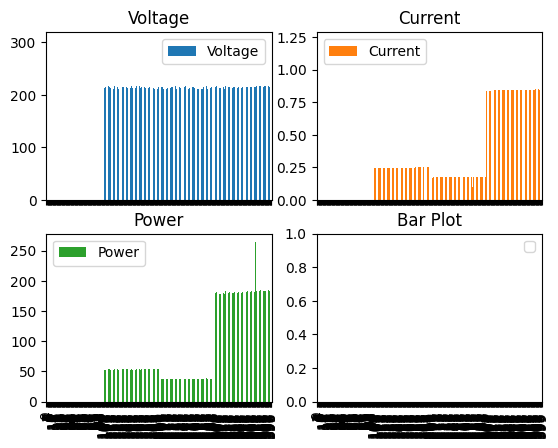

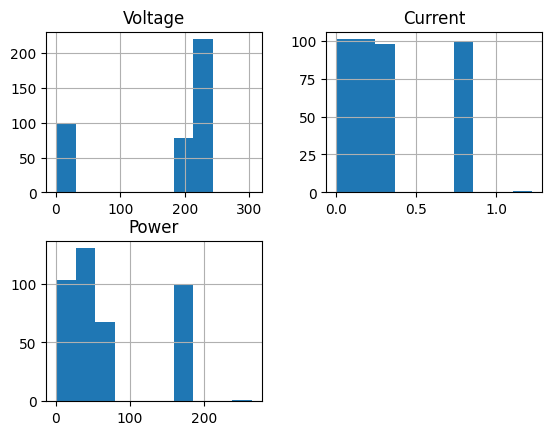

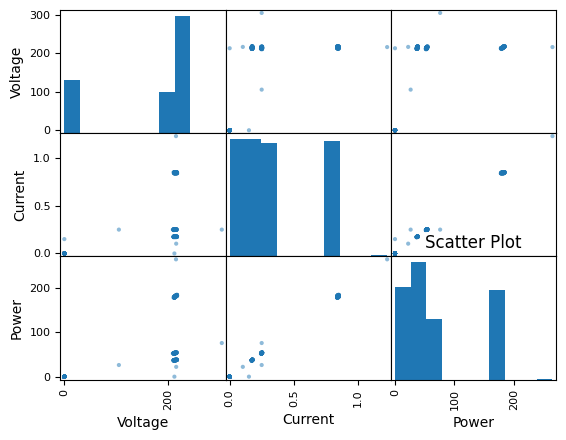

In [4]:
dataset.plot(kind = 'bar', subplots = True, layout = (2, 2))
plt.title('Bar Plot')
plt.show()

dataset.hist()
plt.title('Histogram Plot')
plt.show()

scatter_matrix(dataset)
plt.title('Scatter Plot')
plt.show()

## Evaluating Various ML Algos

In [6]:
array = dataset.values
X = array[:, : -1]
y = array[:, -1]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.2, random_state = 42, shuffle = True)

In [13]:
models = []
models.append(('LR', LogisticRegression(solver = 'lbfgs')))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('SVM', SVC(gamma = 'auto')))

C:\Users\bisht\jupyter_env\tensorflow\torch_env\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\bisht\jupyter_env\tensorflow\torch_env\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/st

LR: 0.993750 (0.012500)
LDA: 0.990625 (0.014321)
KNN: 0.993750 (0.012500)
CART: 0.990625 (0.020010)
SVM: 0.984375 (0.020963)


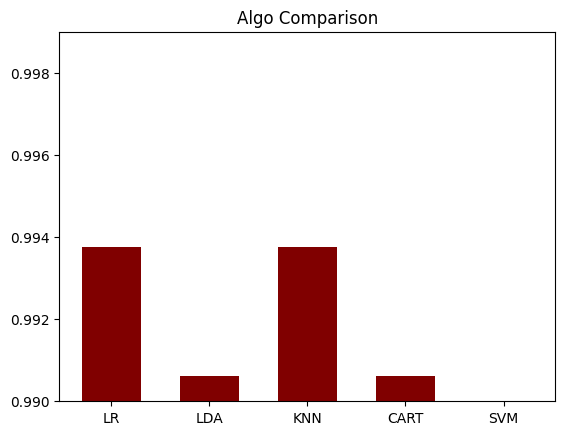

In [14]:
results = []
names = []
res = []
for name, model in models:
    kfold = StratifiedKFold(n_splits = 10, random_state = None)
    cv_results = cross_val_score(model, X_train, y_train, cv = kfold, scoring = 'accuracy')
    results.append(cv_results)
    names.append(name)
    res.append(cv_results.mean())
    print('%s: %f (%f)' % (name, cv_results.mean(), cv_results.std()))

plt.ylim(.990, .999)
plt.bar(names, res, color = 'maroon', width = 0.6)
plt.title('Algo Comparison')
plt.show()